# Section 3: Statistical physics of the state field

Companion notebook for Section 3 of **"Statistical physics of language change inferred from time evolving maps"** (Burridge & Vaux).

**Goal:** construct and simulate the state field model, which combines three physical processes:
1. **Migration** — speakers move between cells according to a gravity model fitted to US county-to-county data
2. **Local copying** — speakers copy variants from nearby speakers at rate *J* over length scale *R*
3. **Selection** — speakers preferentially adopt locally common variants (accommodation, strength *β*) and carry an intrinsic bias *s* toward certain variants

**Key outputs:**

**Note on migration fitting:** the gravity model parameters were estimated from IRS county-to-county data (not included in this repo). The fitted values are used directly here. Fitting code is in `code/migration_model/county_migration.ipynb`.

In [9]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

import glob

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.spatial import distance_matrix

import spatial_model as sm

In [10]:
# Paths — notebook lives in code/state_field_model/
repo_root   = Path().resolve().parents[1]
voronoi_dir = repo_root / 'data' / 'voronois'
p_field_dir = repo_root / 'data' / 'probability_fields'

cmap       = 'RdYlBu_r'
n_demes    = 4000
start_year = 1950
end_year   = 2000

In [11]:
# Load Voronoi tessellation (cell geometries, centroids, populations)
gdf_voronoi = gpd.read_file(voronoi_dir / f'Voronoi_{n_demes}_raw_kmeans_demes.gpkg')

DX   = np.column_stack([gdf_voronoi.x.values, gdf_voronoi.y.values])
dmat = distance_matrix(DX, DX) / 1e3   # pairwise distances in km
pops = gdf_voronoi['pop'].values

N = len(pops)
print(f'N = {N} cells,  total population = {pops.sum() / 1e6:.1f}M')

N = 4000 cells,  total population = 329.2M


## §3(a): Diffusion — migration and local copying

### Migration

Each speaker migrates from cell $i$ to cell $j \neq i$ at rate
$$w_{ij} = c\, P_i^{\alpha-1} P_j^\alpha \,(d_0 + d_{ij})^{-\gamma_0 - \gamma_1 \log(d_0+d_{ij})}$$
with the constant $c$ chosen so that the mean migration rate $\lambda = c P^{-1}\sum_{i,j} f_{ij} = \bar\lambda = 6.3\%$ per year.

Parameters fitted to 2011 IRS county-county data (, Supplement §2):

| Parameter | Value |
|-----------|-------|
| $d_0$ | 48.91 km |
| $\gamma_0$ | 5.57 |
| $\gamma_1$ | −0.35 |
| $\alpha$ | 0.60 |
| $\bar\lambda$ | 6.3% yr⁻¹ |

### Local copying

At rate $J\delta t$ a speaker in cell $i$ copies a variant from a speaker selected from
$$l_{ij} = \frac{P_j \exp\!\left(-d_{ij}^2/2R^2\right)}{\sum_k P_k \exp\!\left(-d_{ik}^2/2R^2\right)}$$
We set $R = 100$ km and $J = 0.1$ (the smallest value producing spontaneous interfaces).

In the continuum limit the copying term contributes an effective diffusion with coefficient $D = JR^2/2$.

The combined expected state field increment from migration and copying is (equation 3.1):
$$\mathbb{E}_t(\delta \mathbf{X}_i) = \sum_j \bigl(w_{ij} + J l_{ij} - (w_i + J)\delta_{ij}\bigr)\,\mathbf{X}_j\,\delta t$$

In [12]:
# Gravity model parameters (fitted, Supplement §2)
d0         = 48.91   # distance offset (km)
gamma0     = 5.57    # distance decay
gamma1     = -0.35   # log-distance correction
alpha_mig  = 0.60    # population exponent
lambda_bar = 0.063   # mean annual migration rate

# Calibrate c to match historical migration rate
c = sm.get_c(pops, dmat, d0, gamma0, gamma1, alpha_mig, lambda_bar)
print(f'Scale constant c = {c:.4g}')

# Build N×N migration generator W  (may take ~1 min for N=4000)
print(f'Building migration generator W ({N}×{N}) ...')
W = sm.migration_generator(dmat, pops, d0, gamma0, gamma1, alpha_mig, c)
print('Done.')

# Verify: population-weighted mean migration rate
cell_rates = -W[np.diag_indices(N)]   # per-cell out-rate
lambda_check = np.sum(pops * cell_rates) / pops.sum()
print(f'Population-weighted mean migration rate: {lambda_check:.3f}  (target {lambda_bar:.3f})')

Scale constant c = 3805
Building migration generator W (4000×4000) ...
Done.
Population-weighted mean migration rate: 0.063  (target 0.063)


In [13]:
# Copying/diffusion generator L  (may take ~1 min for N=4000)
R = 100    # interaction range (km)
J = 0.1    # copying rate — smallest value producing spontaneous interfaces

print(f'Building copying generator L ({N}×{N}), R = {R} km ...')
L = sm.diffusion_generator(dmat, pops, R)
print('Done.')

# Effective diffusion coefficient D = JR²/2 (paper §4(a))
D = J * R**2 / 2
print(f'Effective diffusion coefficient D = JR²/2 = {D:.0f} km²')

Building copying generator L (4000×4000), R = 100 km ...
Done.
Effective diffusion coefficient D = JR²/2 = 500 km²


## §3(b): Selection — replicator dynamics with bias and accommodation

Each speaker in site $s$ of cell $i$ updates its variant according to a fitness-weighted copying process. The fitness of variant $k$ in cell $i$ is
$$q_{ik}(\mathbf{x}) = s_{ik} + \beta\, x_{ik}$$
where $\mathbf{s}_i$ is the **bias vector** (intrinsic variant preference) and $\beta$ is the **accommodation factor** (advantage for locally common variants, i.e. frequency-dependent selection).

In the large-population limit the state field evolves as the **replicator equation** plus diffusion:
$$d\mathbf{X}_i = \underbrace{\bigl(\mathbf{q}_i \circ \mathbf{X}_i - \bar{q}_i\, \mathbf{X}_i\bigr)}_{\text{selection}} dt
+ \underbrace{\sum_j\bigl(w_{ij} + J l_{ij} - (w_i+J)\delta_{ij}\bigr)\mathbf{X}_j}_{\text{migration + copying}} dt
+ d\boldsymbol{\xi}_i \qquad (3.5)$$

The `model` class in `spatial_model.py` integrates this ODE (noise set to zero for deterministic prediction):
- Combine $W + JL$ into a single linear operator $A$
- RHS: $\mathbf{x}\circ(\mathbf{q} - \bar{q}) + A\mathbf{x}$
- Integrate via `scipy.integrate.odeint`

## Phase ordering from a primordial state

Starting from a random initial condition (each cell drawn uniformly from the simplex), we evolve the model for $T = 50$ years with bias $\mathbf{s} = 0$, accommodation $\beta = 0.2$, and six values of the copying rate $J$.

At $J = 0$ the system remains disordered. As $J$ increases, single-variant domains emerge with smooth boundaries — the linguistic analogue of physical **phase ordering** driven by surface tension.

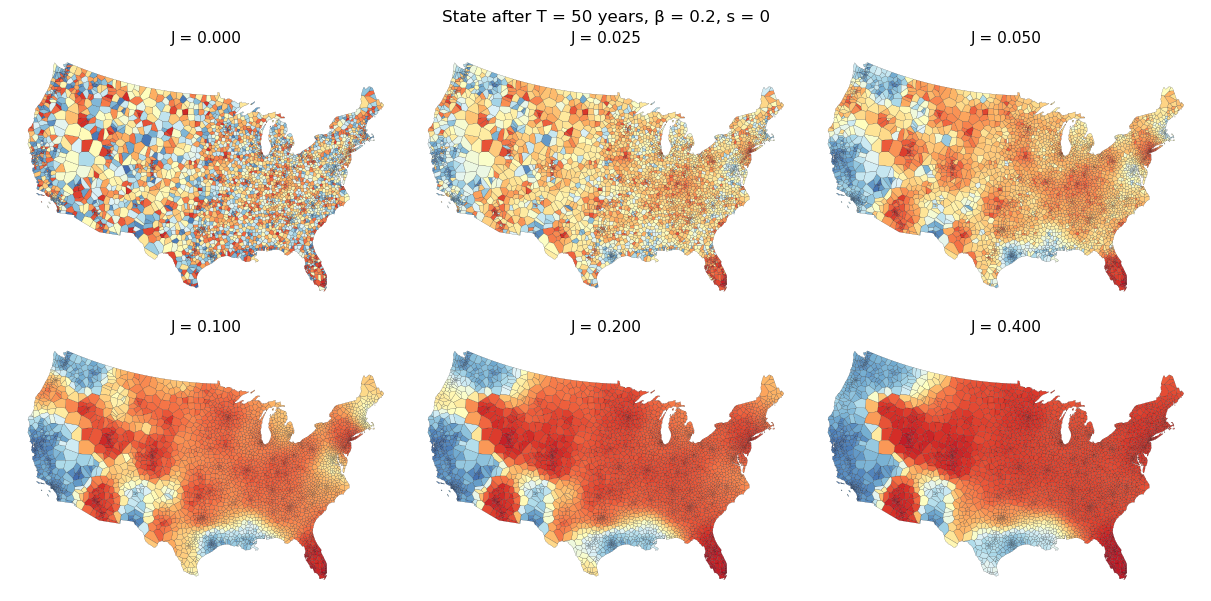

In [14]:
rng  = np.random.default_rng(seed=42)
K    = 2
Js   = [0.0, 0.025, 0.05, 0.1, 0.2, 0.4]
T_end = 50
ts   = np.arange(T_end + 1)
beta = 0.2
s    = np.zeros((N, K))   # no bias

# Random initial state: x_1 ~ U[0,1], x_2 = 1 - x_1
x00 = rng.uniform(0.0, 1.0, N)
X0  = np.column_stack([x00, 1.0 - x00])

fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for ax, J_val in zip(axs.ravel(), Js):
    mod  = sm.model(W, L, J_val, s, beta, X0)
    xsol = mod.solve(ts)   # shape (T+1, N, K)
    gdf_voronoi.plot(
        column=xsol[-1, :, 0], ax=ax,
        cmap=cmap, vmin=0, vmax=1,
        linewidth=0.1, edgecolor='k'
    )
    ax.set_axis_off()
    ax.set_title(f'J = {J_val:.3f}', fontsize=11)

plt.suptitle(f'State after T = {T_end} years, β = {beta}, s = 0', fontsize=12)
plt.show()

## The sneakers/tennis isogloss — accommodation vs. migration

The *sneakers* vs. *tennis shoes* boundary illustrates the role of accommodation in maintaining dialect boundaries against levelling by migration.

We initialise the model at the 1950 MAP field and evolve to 1995 under three scenarios:
1. **Empirical** — the inferred MAP field at each time
2. **Migration only** — $J = 0.1$, $\beta = 0$, $\mathbf{s} = 0$  
3. **Migration + accommodation + bias** — $J = 0.1$, $\beta = 0.20$, $|s| = 0.024$

Without accommodation, migration rapidly destroys the isogloss. With accommodation, the boundary is maintained — the condition for stability is $\beta > 2\lambda \approx 0.12$ (§4(a)).

In [15]:
# Load pre-computed tennis/sneakers MAP field (v_4)
sneakers_files = glob.glob(str(p_field_dir / 'v_4_tennis_sneakers_*.npy'))
assert sneakers_files, 'No tennis_sneakers v_4 field found in data/probability_fields/'
P = np.load(sneakers_files[0])      # shape (N, T, K)
variant_names = ['tennis', 'sneakers']
print(f'Loaded: {Path(sneakers_files[0]).name}, shape {P.shape}')

# Initial condition: 1950 MAP field
X0_snk = P[:, 0, :].copy()

# Time axis for predictions 1950 → 1995
T_pred = 45
ts_pred = np.arange(T_pred + 1)

# Spatially constant bias inferred from data (§4)
beta_fit = 0.20
s_fit    = np.array([-0.024, 0.024])   # bias against tennis, toward sneakers

# --- Run simulations ---
# 1. Migration only (β=0, s=0, J=0.1)
mod_mig  = sm.model(W, L, J, np.zeros((N, 2)), 0.0, X0_snk)
sol_mig  = mod_mig.solve(ts_pred)    # (T+1, N, K)

# 2. Full model (β=0.20, s fitted, J=0.1)
mod_full = sm.model(W, L, J, s_fit, beta_fit, X0_snk)
sol_full = mod_full.solve(ts_pred)   # (T+1, N, K)

Loaded: v_4_tennis_sneakers_4000_demes_tau_28_sigma_304_alpha_0.07_var_1.0_start_1950_end_2000.npy, shape (4000, 51, 2)


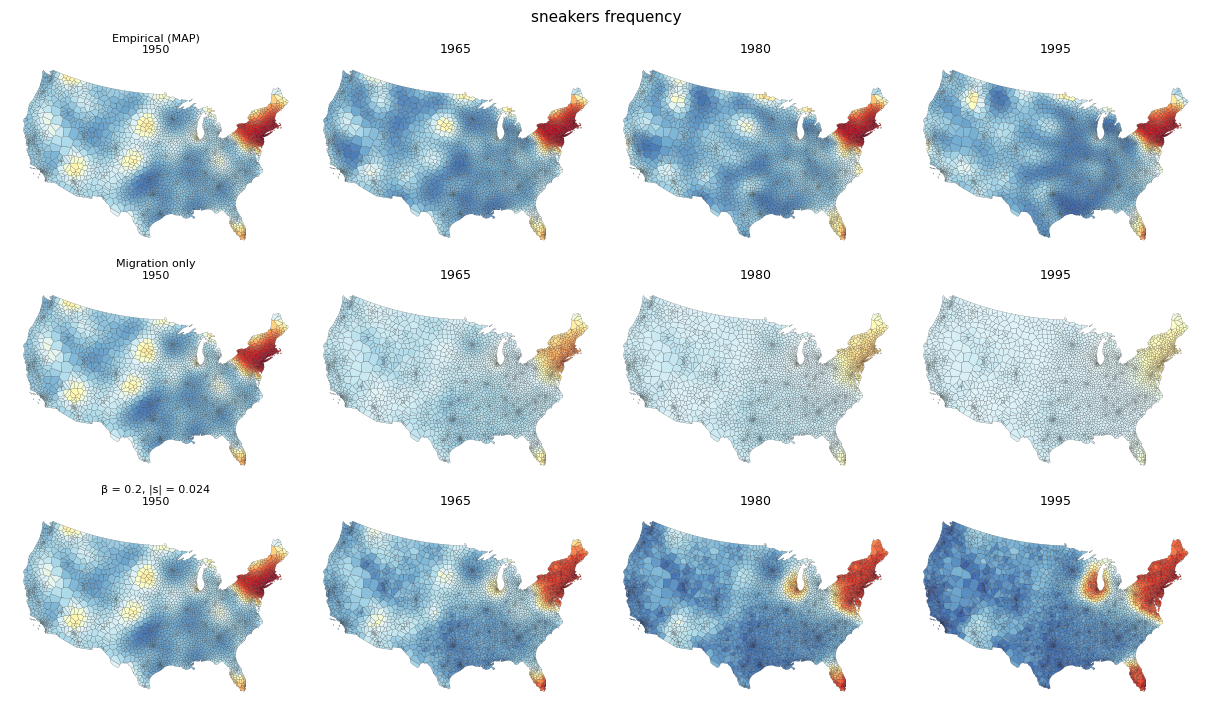

In [16]:
# Plot: three rows (empirical / migration only / full model), four time slices
plot_years   = [1950, 1965, 1980, 1995]
row_labels   = ['Empirical (MAP)',
                'Migration only',
                f'β = {beta_fit}, |s| = {abs(s_fit[0]):.3f}']
sneakers_idx = 1   # plot sneakers (index 1)

fig, axs = plt.subplots(3, 4, figsize=(12, 7), constrained_layout=True)

for col, yr in enumerate(plot_years):
    t_emp = yr - start_year
    t_mod = yr - 1950

    rows_data = [
        P[:, t_emp, sneakers_idx],
        sol_mig[t_mod, :, sneakers_idx],
        sol_full[t_mod, :, sneakers_idx],
    ]
    for row, data in enumerate(rows_data):
        ax = axs[row, col]
        gdf_voronoi.plot(
            column=data, ax=ax,
            cmap=cmap, vmin=0, vmax=1,
            linewidth=0.1, edgecolor='k'
        )
        ax.set_axis_off()
        if col == 0:
            ax.set_title(f'{row_labels[row]}\n{yr}', fontsize=8)
        else:
            ax.set_title(str(yr), fontsize=9)

plt.suptitle('sneakers frequency', fontsize=11)
plt.show()